## Walmart Data analysis using python and sql 

In [1]:
#Data Cleaning process 
import pandas as pd 
df = pd.read_csv(r"C:\Users\Sara\Downloads\Walmart.csv")
df

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48
...,...,...,...,...,...,...,...,...,...,...,...
10046,9996,WALM056,Rowlett,Fashion accessories,$37,3.0,03/08/23,10:10:00,Cash,3.0,0.33
10047,9997,WALM030,Richardson,Home and lifestyle,$58,2.0,22/02/21,14:20:00,Cash,7.0,0.48
10048,9998,WALM050,Victoria,Fashion accessories,$52,3.0,15/06/23,16:00:00,Credit card,4.0,0.48
10049,9999,WALM032,Tyler,Home and lifestyle,$79,2.0,25/02/21,12:25:00,Cash,7.0,0.48


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  object 
 2   City            10051 non-null  object 
 3   category        10051 non-null  object 
 4   unit_price      10020 non-null  object 
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  object 
 7   time            10051 non-null  object 
 8   payment_method  10051 non-null  object 
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 863.9+ KB


In [3]:
# find all duplicate 
df.duplicated().sum()

np.int64(51)

In [4]:
#dropping all the duplicates 
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [5]:
#finding null values
df.isnull().sum()

invoice_id         0
Branch             0
City               0
category           0
unit_price        31
quantity          31
date               0
time               0
payment_method     0
rating             0
profit_margin      0
dtype: int64

In [6]:
#droping the null values
df.dropna(inplace = True)
df.isnull().sum()

invoice_id        0
Branch            0
City              0
category          0
unit_price        0
quantity          0
date              0
time              0
payment_method    0
rating            0
profit_margin     0
dtype: int64

In [7]:
df.dtypes

invoice_id          int64
Branch             object
City               object
category           object
unit_price         object
quantity          float64
date               object
time               object
payment_method     object
rating            float64
profit_margin     float64
dtype: object

In [8]:
#changing the datatype into float
df['unit_price'] = df['unit_price'].str.replace('$', '').astype(float)
df

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,WALM056,Rowlett,Fashion accessories,37.00,3.0,03/08/23,10:10:00,Cash,3.0,0.33
9996,9997,WALM030,Richardson,Home and lifestyle,58.00,2.0,22/02/21,14:20:00,Cash,7.0,0.48
9997,9998,WALM050,Victoria,Fashion accessories,52.00,3.0,15/06/23,16:00:00,Credit card,4.0,0.48
9998,9999,WALM032,Tyler,Home and lifestyle,79.00,2.0,25/02/21,12:25:00,Cash,7.0,0.48


In [9]:
#Columns datatypes
df.dtypes

invoice_id          int64
Branch             object
City               object
category           object
unit_price        float64
quantity          float64
date               object
time               object
payment_method     object
rating            float64
profit_margin     float64
dtype: object

In [10]:
#keeping lowercase column
df.columns = df.columns.str.lower()
df.columns

Index(['invoice_id', 'branch', 'city', 'category', 'unit_price', 'quantity',
       'date', 'time', 'payment_method', 'rating', 'profit_margin'],
      dtype='object')

In [11]:
#creating another column to find the total amount
df['total_amount'] = df['unit_price'] * df['quantity']
df.head()

,invoice_id,branch,city,category,unit_price,quantity,date,time,payment_method,rating,profit_margin,total_amount
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48,522.83
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48,76.40
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33,324.31
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33,465.76
4,5,WALM013,Irving,Sports and travel,86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48,604.17


In [12]:
#description of walmart data
df.describe()

,invoice_id,unit_price,quantity,rating,profit_margin,total_amount
count,9969.000000,9969.000000,9969.000000,9969.000000,9969.000000,9969.000000
mean,5010.116561,50.622142,2.355602,5.828839,0.393744,121.348819
std,2886.217349,21.203766,1.605455,1.763723,0.090659,112.678040
min,1.000000,10.080000,1.000000,3.000000,0.180000,10.170000
25%,2524.000000,32.000000,1.000000,4.000000,0.330000,54.000000
50%,5016.000000,51.000000,2.000000,6.000000,0.330000,88.000000
75%,7508.000000,69.000000,3.000000,7.000000,0.480000,156.000000
max,10000.000000,99.960000,10.000000,10.000000,0.570000,993.000000


## Conecting jupyter notebook to SQL Server Mamangement Studio

In [13]:
!pip install pymysql sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import pyodbc
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [15]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

driver = quote_plus("ODBC Driver 18 for SQL Server")

engine = create_engine(
    f"mssql+pyodbc://@localhost\\SQLEXPRESS/Walmart"
    f"?driver={driver}&trusted_connection=yes&TrustServerCertificate=yes"
)

In [17]:
df.to_sql("WalmartSales",con=engine,if_exists="replace",index=False)

51

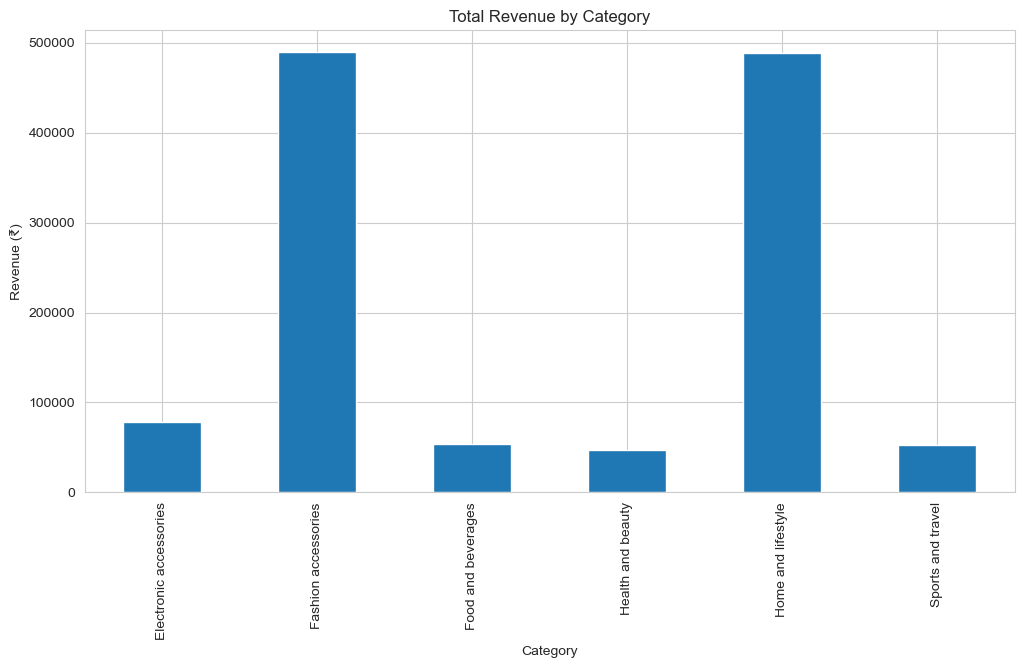

In [29]:
import matplotlib.pyplot as plt
import os

# Create visualizations folder if it doesn't exist
os.makedirs('visualizations', exist_ok=True)

# Chart 3: Revenue By Category 
df.groupby('category')['total_amount'].sum().plot(kind='bar')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.savefig('visualizations/revenue_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

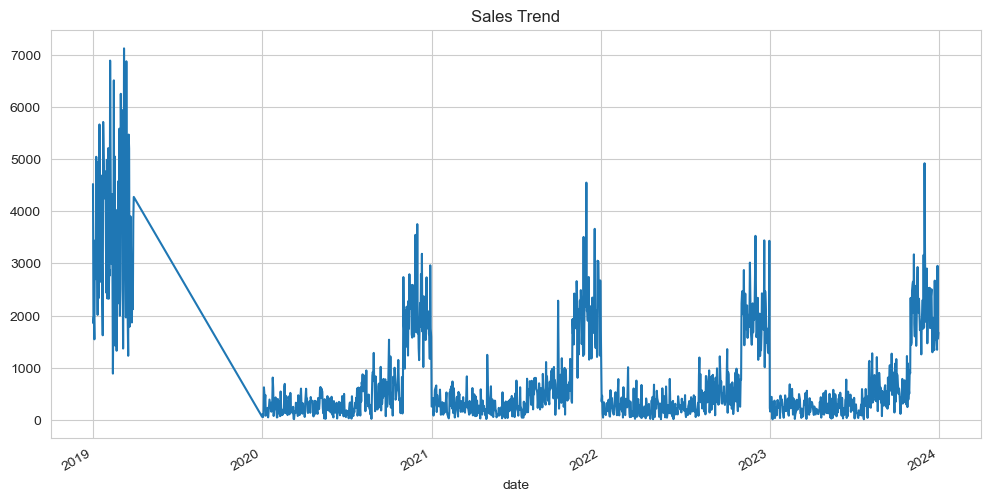

In [27]:
# Line Chart of sales trend
df.groupby('date')['total_amount'].sum().plot(kind='line')
plt.title('Sales Trend')
plt.savefig('visualizations/sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

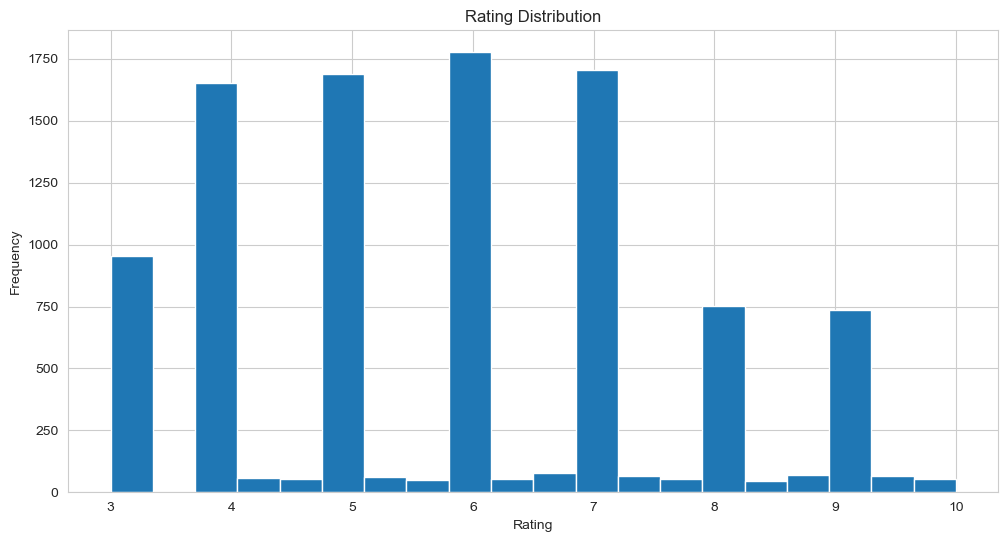

In [28]:
# Distribution of ratings
df['rating'].hist(bins=20)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.savefig('visualizations/rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()